<a href="https://colab.research.google.com/github/fehmidataj27-dotcom/desktop-tutorial/blob/main/Fake%20news%20Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

In [ ]:
data = pd.read_csv("/content/fake_news_dataset (1).csv")
data.head()

,text,label
0,Government announces new education policy,0
1,Scientists discover new species in Amazon forest,0
2,Stock market shows steady growth this quarter,0
3,Health ministry launches new vaccination drive,0
4,Aliens have landed in New York claims social m...,1


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    200 non-null    object
 1   label   200 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 3.3+ KB


In [ ]:
data.describe()

,label
count,200.000000
mean,0.600000
std,0.491127
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


In [ ]:
def clean_text(text):
    text = re.sub('[^a-zA-Z]', ' ', text)
    text = text.lower()
    words = text.split()
    words = [w for w in words if w not in stopwords.words('english')]
    return ' '.join(words)

data['text'] = data['text'].apply(clean_text)


In [ ]:
X = data['text']
y = data['label']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)


In [ ]:
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)


In [ ]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [ ]:
def check_news(news):
    news = clean_text(news)
    news_vec = vectorizer.transform([news])
    result = model.predict(news_vec)
    if result[0] == 1:
        print("Fake News")
    else:
        print("Real News")

check_news("Breaking news: Scientists discover new planet")


Real News


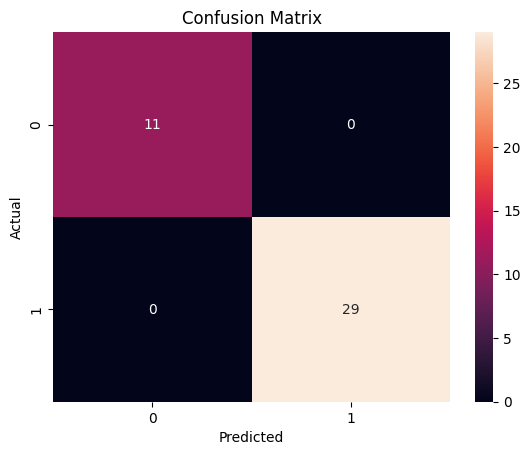

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()